In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples

plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:
BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5
NUM_BDTS = 10


ZUKO_ID = "NCSF"
NAME = "VBC_S_2048"
BATCH_SIZE = 512
NUM_COND_INPUTS = 0
COLLECTION_NAME = "VertexBarrelCollection"
SEED = 8

EVALUATE_SAMPLES = False


working_dir = "/pscratch/sd/r/rmastand/muon_collider"

In [4]:
save_dir = f"{working_dir}/zuko_outputs/{ZUKO_ID}/{NAME}"


with open(f"{save_dir}/wandb/latest-run/files/config.yaml") as ifile:
    configs = yaml.safe_load(ifile)

In [5]:

# computingtorch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:

feature_labels = ["log($E$) [Gev]", "$x$", "$y$", "$z$", "$t$ [s]", "context"]
log_vars = []

In [7]:
data = load_in_data([COLLECTION_NAME], "xy", working_dir, 0.1)[0]
        

bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 5), np.max(data[:,i] + 5), NUM_BINS) 

In [8]:


X_preproc = preprocess_data(data, ".", ZUKO_ID)
if NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()



In [9]:


hidden_features = [int(x) for x in configs["HIDDEN_FEATURES"]["value"].split(",")]


if ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features).to(device)
elif ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features, bins=16).to(device)
elif ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features, degree=4, polynomials=3).to(device)
elif ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features).to(device)
elif ZUKO_ID == "CNF":
    flow = zuko.flows.CNF(5, 0, hidden_features=hidden_features, freqs=configs["FREQS"]["value"]).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()


num_params = count_parameters(flow)
print(f"Number of trainable parameters: {num_params}")



Number of trainable parameters: 192321


In [10]:


print("Making flow samples...")

eval_flow = flow

eval_flow.load_state_dict(torch.load(f"{save_dir}/test.pt"))

num_samples_total = data.shape[0] 
sample_batch_size = 8192

samples_flow = []
for i in tqdm(range(0, num_samples_total, sample_batch_size)):
    if i + sample_batch_size > num_samples_total:
        nn = num_samples_total - i
    else:
        nn = sample_batch_size
    loc_samples = eval_flow().sample((nn,)).detach().cpu().numpy()
    samples_flow.append(loc_samples)
samples_flow = np.concatenate(samples_flow)

X_samples = {
        "flow_samples":samples_flow
        }



Making flow samples...


100%|██████████| 33/33 [00:23<00:00,  1.41it/s]


In [11]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , ".", ZUKO_ID)

auc 0.6298278807616047 \pm 0.00020780628997892113. best epoch 299 of 300.



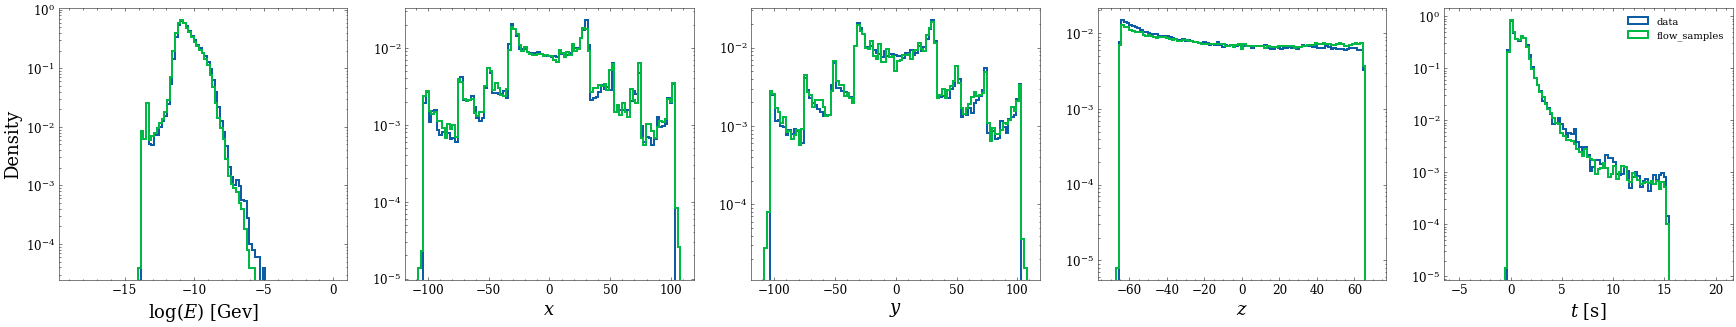

In [12]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars, labels=feature_labels)


try:
    with open(f"{save_dir}/results.txt") as ifile:
        a = ifile.readlines()[-1]
        print(a)
except:
    pass

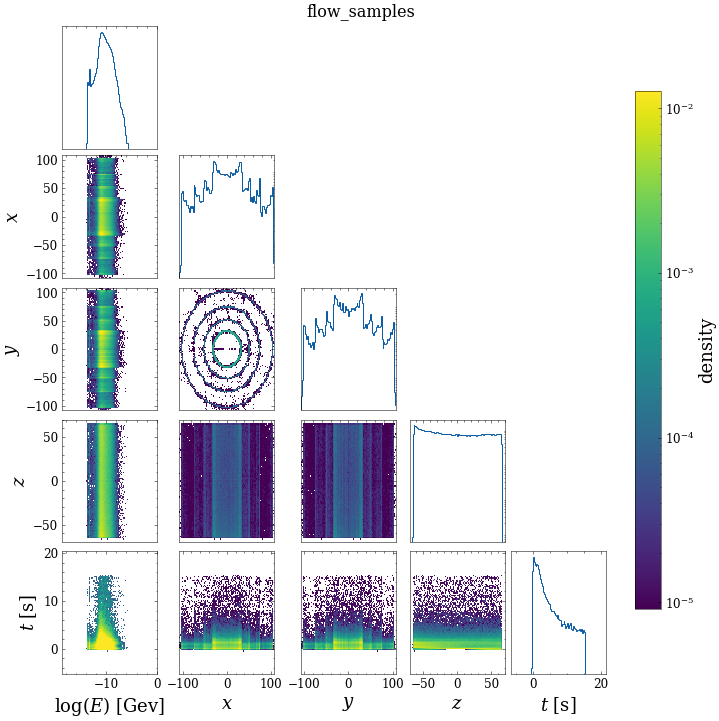

In [13]:
for key in X_samples.keys():
    fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )



# Restrict layers

(<Figure size 2160x360 with 5 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$x$'>, <Axes: xlabel='$y$'>, <Axes: xlabel='$z$'>,
        <Axes: xlabel='$t$ [s]'>], dtype=object))

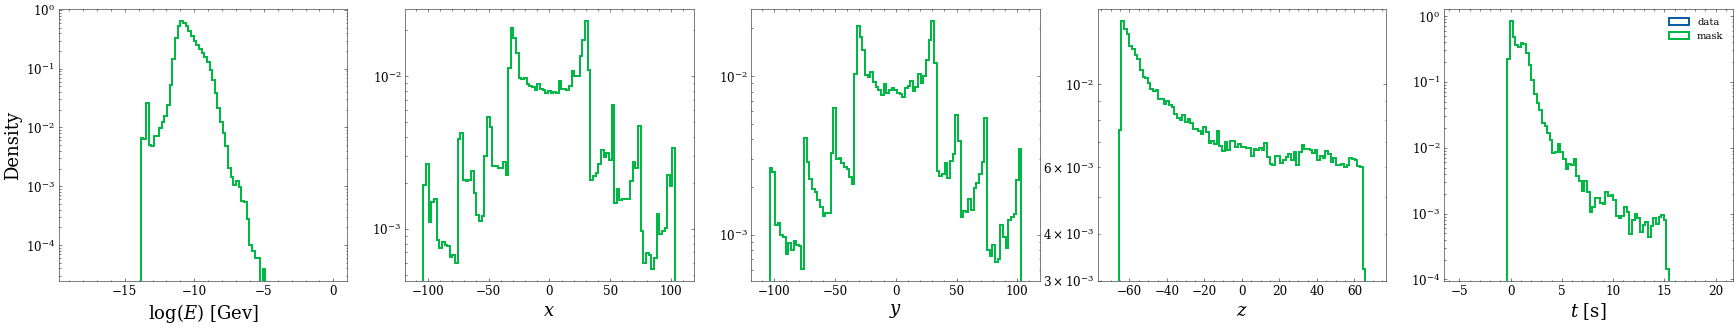

In [14]:

# https://github.com/key4hep/k4geo/blob/main/MuColl/MAIA/compact/MAIA_v0/OuterTracker_o2_v06_01.xml



def make_mask(r):

    with open("mask_definitions.pkl", "rb") as ifile:
        mask_definitions = pickle.load(ifile)

    mask = []
    for i in range(len(mask_definitions[COLLECTION_NAME]["lower_bounds"])):
       

        tmp = (
            (r >= mask_definitions[COLLECTION_NAME]["lower_bounds"][i]) &
            (r <= mask_definitions[COLLECTION_NAME]["upper_bounds"][i])
        )

        mask.append(tmp.reshape(-1,1))

    mask = np.any(np.hstack(mask), axis=1)

    return mask

m = make_mask(np.sqrt(data[:,1]**2+data[:,2]**2))

plot_hists_1d({"data":data, "mask":data[m]}, bins_dict, log_dims=log_vars, labels=feature_labels)



264185 244115 0.9240305089236709


(<Figure size 2160x360 with 5 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$x$'>, <Axes: xlabel='$y$'>, <Axes: xlabel='$z$'>,
        <Axes: xlabel='$t$ [s]'>], dtype=object))

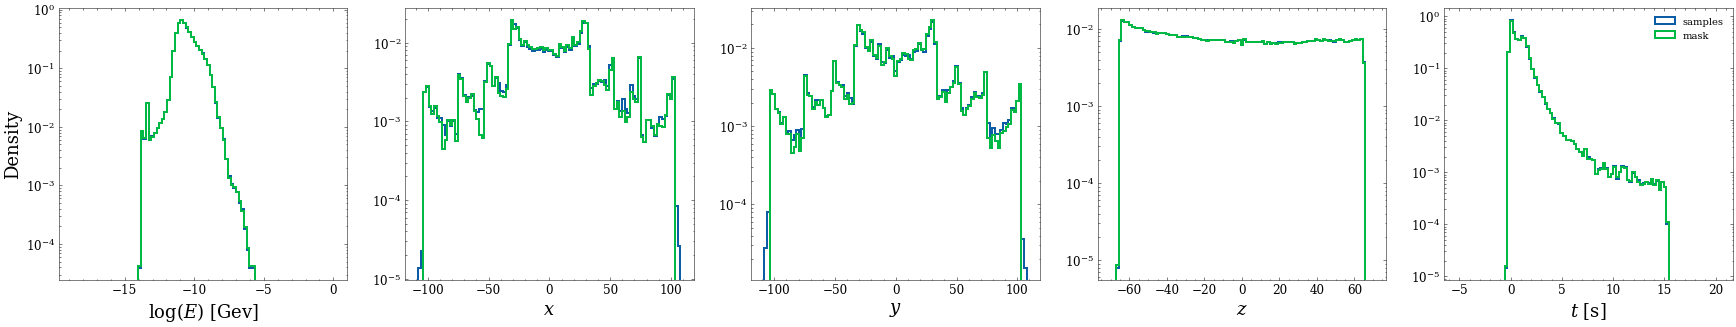

In [15]:
m = make_mask(np.sqrt(X_samples["flow_samples"][:,1]**2+X_samples["flow_samples"][:,2]**2))
print(len(m), sum(m), sum(m)/len(m))

plot_hists_1d({"samples":X_samples["flow_samples"], "mask":X_samples["flow_samples"][m]}, bins_dict, log_dims=log_vars, labels=feature_labels)


NCSF VBC_S_2048


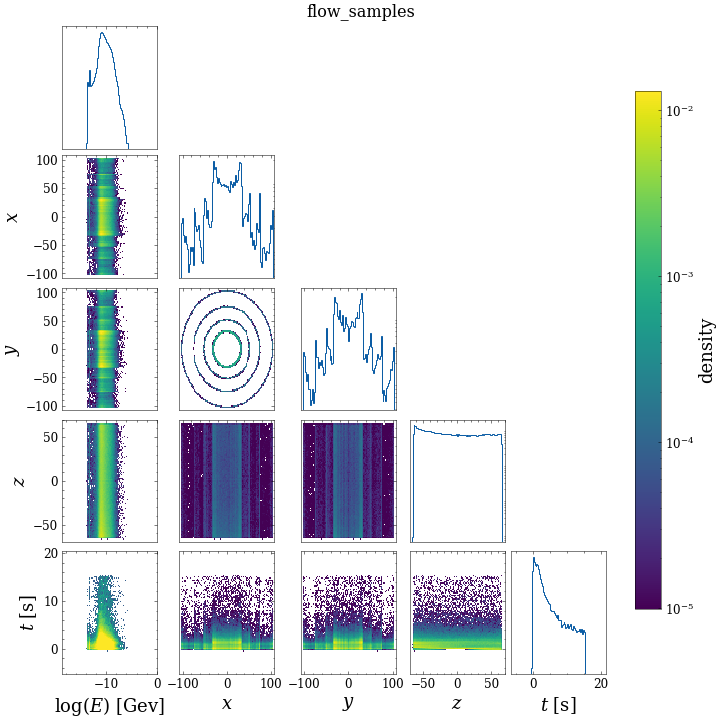

In [16]:
print(ZUKO_ID, NAME)


fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key][m],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )

In [17]:
if EVALUATE_SAMPLES:
    ks_dists_samples = get_kl_dist(data, X_samples["flow_samples"])
    ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples["flow_samples"].shape))
    
                                            
    for i, ks_dist in enumerate(ks_dists_samples):
        print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
    
    auc_mean, auc_std, best_epoch_list, max_epochs, bdt_list = discriminate_data_from_samples(data,  X_samples["flow_samples"], n_runs=NUM_BDTS, bdt_config="configs/bdt.yml")
    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
    


In [18]:
if EVALUATE_SAMPLES:
    loc_scores = []
    for i, bdt_i in enumerate(bdt_list):
    
        loc_scores.append(bdt_i.predict_proba(
                X_samples["flow_samples"], iteration_range=(0, best_epoch_list[i])
            )[:, 0].reshape(-1, 1))
    
    loc_scores = np.mean(np.concatenate(loc_scores, axis = 1), axis = 1)
                        
    
    plt.figure()
    plt.hist(loc_scores, bins = np.linspace(0, 1, 100), histtype = "step", density = True)
    plt.xlabel("scores")
    plt.ylabel("Density")
    plt.show()
    
    
    X_plot = {"samples":  X_samples["flow_samples"]}
    
    percentiles = [50, 90, 99]
    
    for p in percentiles:
        X_plot[f"samples, top {p}%"] =  X_samples["flow_samples"][loc_scores >= np.percentile(loc_scores, p)]
    
    
    
    plot_hists_1d({"data":data, **X_plot}, bins_dict, log_dims=log_vars, labels=feature_labels)
    
    


In [19]:
if EVALUATE_SAMPLES:
    ks_dists_samples = get_kl_dist(data, X_samples["flow_samples"][m])
    ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples["flow_samples"][m].shape))
    
                                            
    for i, ks_dist in enumerate(ks_dists_samples):
        print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
    
    auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples["flow_samples"][m], n_runs=NUM_BDTS, bdt_config="configs/bdt.yml")
    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")

In [20]:

np.save(f"{working_dir}/npys/flow_samples/{COLLECTION_NAME}_{ZUKO_ID}_{NAME}.npy", X_samples["flow_samples"] )


